# Day 5 — Linear Regression (USA Housing) 🏠
**Kaj:** house **Price** (continuous number) predict kora. Supervised · Regression.

> ⚙️ **Kernel:** upore-daane kernel picker theke **"Python (LAB-FINAL-2)"** select koro (na hole pandas/sklearn import fail korbe).
>
> ▶️ Cell run: `Shift+Enter`. Sob ekbare: menu **Run → Run All Cells**.
>
> 📝 Practice tip: ekbar niche porjonto run koro, tarpor cell muche nijer hate abar likhe dekho.

## 1. Import libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Data porा o dekha

In [20]:
USAhousing = pd.read_csv('day-05__USA_Housing.csv')
USAhousing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [21]:
USAhousing.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [22]:
USAhousing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [23]:
USAhousing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

## 3. EDA (Exploratory Data Analysis)
- `pairplot` = feature gulor moddhe somporko.
- Price er distribution (normal-er moto?).
- `heatmap(corr)` = kon feature Price-er sathe beshi correlated (Avg. Area Income sob theke beshi, ~0.64).

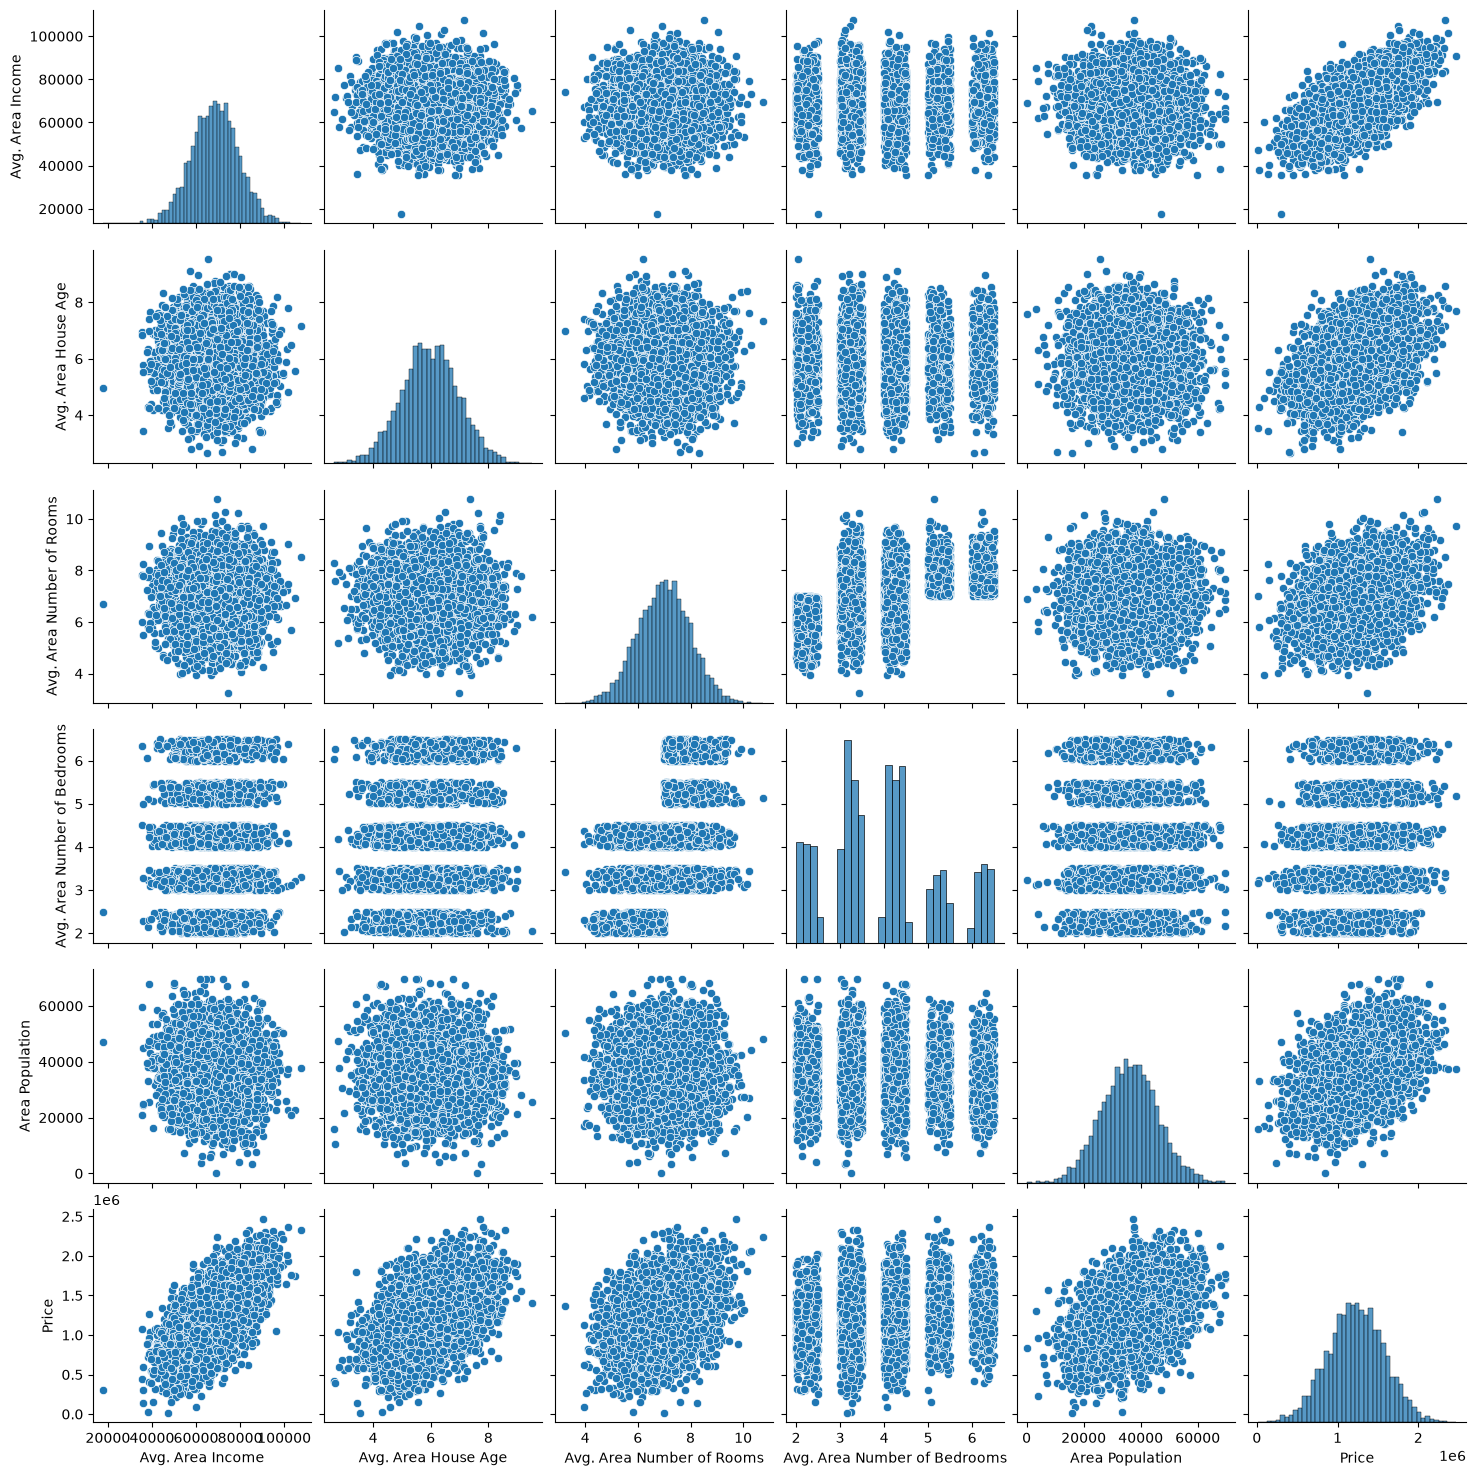

In [24]:
sns.pairplot(USAhousing)   # ektu somoy nite pare (5000 row)

<Axes: xlabel='Price', ylabel='Count'>

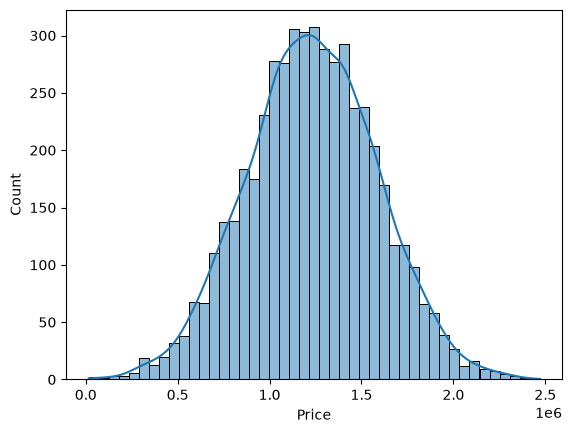

In [25]:
# Lab-e chilo sns.distplot(...); notun seaborn-e histplot use kori (same kaj)
sns.histplot(USAhousing['Price'], kde=True)

<Axes: >

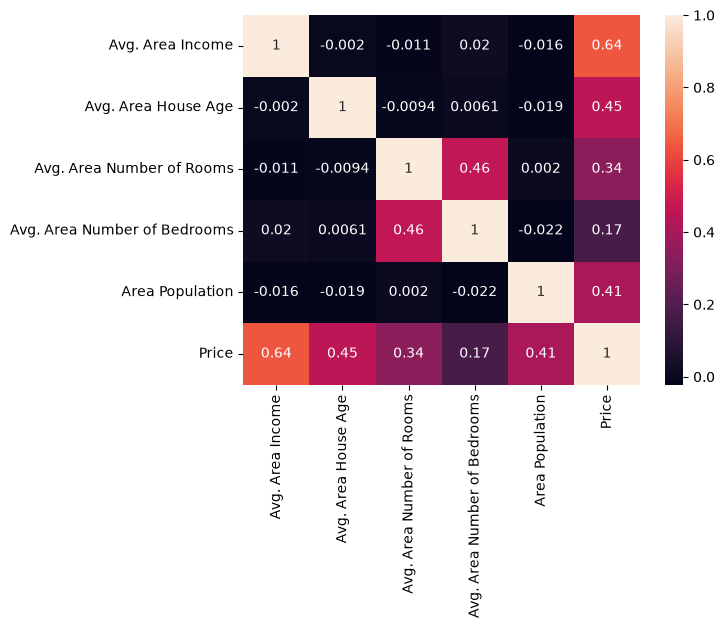

In [26]:
# numeric_only=True -> text column 'Address' baad diye correlation
sns.heatmap(USAhousing.corr(numeric_only=True), annot=True)

## 4. X (features) o y (target) banano
`Address` text column baad — model number chai. `Price` = target.

In [27]:
X = USAhousing[['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms',
                'Avg. Area Number of Bedrooms','Area Population']]
y = USAhousing['Price']

## 5. Train / Test split
Data ke train (shekhar) + test (jachai) e bhag kori. `random_state=101` -> proti baar eki split.

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## 6. Model train (fit)

In [29]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.53,164883.28,122368.68, 2233.8 , 15.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.64e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## 7. Model evaluation — coefficients
`intercept_` = sob feature 0 hole base value. `coef_` = 1 unit barle Price koto bare.

In [30]:
print('Intercept:', lm.intercept_)
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

Intercept: -2640159.7968526953


,Coefficient
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


## 8. Predictions o dekha
scatter(y_test, predictions) prai straight line hole model bhalo. Residual (error) normal hole bhalo.

Text(0, 0.5, 'Predicted Price')

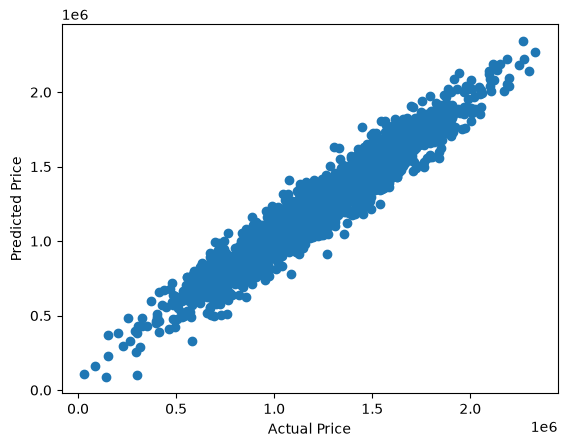

In [31]:
predictions = lm.predict(X_test)
plt.scatter(y_test, predictions)
plt.xlabel('Actual Price'); plt.ylabel('Predicted Price')

<Axes: xlabel='Price', ylabel='Count'>

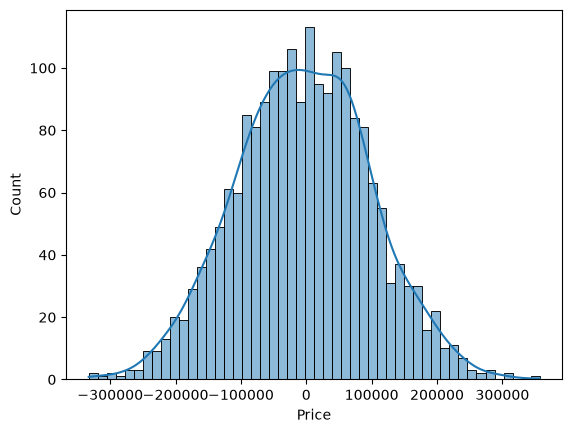

In [32]:
# Residual = actual - predicted ; normal distribution hole model assumption thik
sns.histplot((y_test - predictions), bins=50, kde=True)

## 9. Regression metrics (MAE / MSE / RMSE / R²)
Sob **loss** — jato kom tato bhalo. RMSE target-er (dollar) same unit e, tai interpret sohoj. R² 0-1 (1 = perfect), higher better.

In [33]:
from sklearn import metrics
print('MAE :', metrics.mean_absolute_error(y_test, predictions))
print('MSE :', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2  :', metrics.r2_score(y_test, predictions))

MAE : 82288.22251914942
MSE : 10460958907.208977
RMSE: 102278.82922290897
R2  : 0.9176824009649241


✅ **Sesh.** Ei eki skeleton (read → X/y → split → fit → predict → evaluate) Day 6/7 teo ghure ashe — shudhu model line ar metric palte.